# Lab Sheet 7

In [4]:
from header import *

Integrals of rational functions can be expressed in a number of different, but mathematically equivalent, ways.  The standard function `sp.integral(f, x)` returns a result which depends in a rather random way on the detailed structure of the function `f`.  We therefore write a function `ratint(f, x)` that expresses the integral in a more coherent and systematic way.

In [5]:
def ratint(f, x):
    global ms
    f = sp.factor(f)
    nf = sp.expand(sp.numer(f))
    df = sp.expand(sp.denom(f))
    nfd = sp.degree(nf, x)
    dfd = sp.degree(df, x)
    d = nfd - dfd
    rs0 = sp.Poly(df,x).all_roots(multiple=False)
    rs = []
    for r in rs0:
        if isinstance(r[0],sp.CRootOf):
            r = (r[0].evalf(),r[1])
        rs.append(r)
    c = df.coeff(x, dfd)

    i = 0
    ps = []
    for r, m in rs:
        if sp.im(r) < 0:
            continue
        elif sp.im(r) == 0:
            ps.append((i, x - r, m))
            i += 1
        else:
            ps.append((i, x**2 - 2*sp.re(r)*x + sp.re(r)**2 + sp.im(r)**2, m))
            i += 1
    qs = []
    for i, p in enumerate(ps):
        qs.append((p[0], p[1], p[2], c*sp.Mul(*[p1[1] ** p1[2] for p1 in ps if p1[0] != p[0]])))
    ms = [[x**i, x**i*df, x**(i+1)/(i+1)] for i in range(d+1)]
    for q in qs:
        n = sp.degree(q[1], x)
        m = q[2]
        if n == 1:
            ms.append([1/q[1],q[1]**(m-1)*q[3],sp.log(abs(q[1]))])
            for i in range(2, m+1):
                ms.append([q[1]**(-i), q[1]**(m-i)*q[3], q[1]**(1-i)/(1-i)])
        else:
            a = q[1].coeff(x, 1)
            b = q[1].coeff(x, 0)
            u = 1/sp.sqrt(b - a**2/4)
            v = a*u/2
            ms.append([1/q[1], q[1]**(m-1)*q[3], u * sp.atan(u*x+v)])
            ms.append([(2*x+a)/q[1], (2*x+a) * q[1]**(m-1)*q[3], sp.log(abs(q[1]))])
            for i in range(1, 2*m-1):
                u = i * x**(i-1) * q[1] + (1-m) * x**i * (2*x+a)
                ms.append([u*q[1]**(-m), u, x**i*q[1]**(1-m)])

    a = sp.IndexedBase('a')
    err = sp.collect(sp.expand(nf - sp.Add(*[a[i] * m[1] for i, m in enumerate(ms)])),x)
    sol = sp.solve(sp.Poly(err,x).coeffs())
    F = sp.Add(*[a[i] * m[2] for i, m in enumerate(ms)]).subs(sol)
    return F

We now define a list of functions $g_0,\dotsc,g_9$ which are good test cases for our integration routine.

In [6]:
x = sp.symbols('x')

g = [
 x**2 + x + 1 + 1/x + 1/x**2,
 1/(x-1) + 1/(x**2-1) + 1/(x**3-1),
 1/(x-1)**2 + 1/(x-2)**3 + 1/(x-3)**4,
 1/(x+1) + 1/(x**2+1) + 1/(x**3+1),
 x/(x+1)*(x+2)/(x+3)*(x+4),
 x/(x+1)**2*(x+2)/(x+3)**2*(x+4),
 (x**3+4*x**2+x+2)/(x-1)**2/(x+1)**3,
 1/(x**2+8*x+1),
 (x**2+1)**(-5),
 1/(x**8+x**2+1),
]

Exercise 1

In [9]:
y = ((x**3+1)/(x**2+1))**3
Y = ratint(y, x)
display(Latex("Here we consider the function $y=" + sp.latex(y) + "$."))
display(Latex("The integral is $Y=" + sp.latex(Y) + "$."))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Here we plot all the different terms in $Y$ separately.  It is clear that the term $x^4/4$ is larger than all the other terms already when $x=6$, and this effect will become stronger as $x$ increases.  To understand this, note that when $x$ is large the $+1$ terms in the definition of $y$ will become negligible, so $y$ will be close to $(x^3/x^2)^3=x^3$, so the main term integral will be $\int x^3\,dx=x^4/4$. 

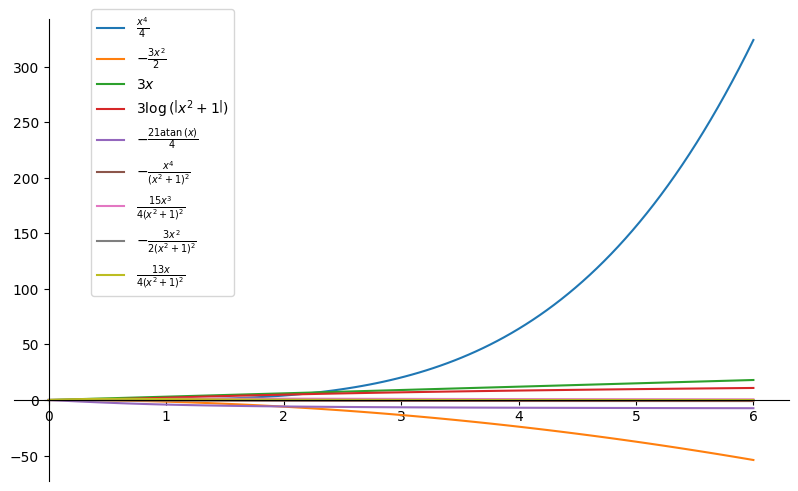

In [8]:
Y_terms = list(Y.args)
Y_terms = [t[1] for t in sorted([(-abs(t.subs({x:5}).evalf()),t) for t in Y_terms])]
xs = np.linspace(0, 6, 100)
fig, ax = plt.subplots(figsize=(10,6))
for t in Y_terms:
    t_fun = sp.lambdify(x, t, 'numpy')
    ax.plot(xs, t_fun(xs), label='$' + sp.latex(t) + '$')
fix_axes(ax)
ax.legend(loc=(0.1,0.4))

We now plot $Y$ and $x^4/4$ together to see that they are approximately the same. 

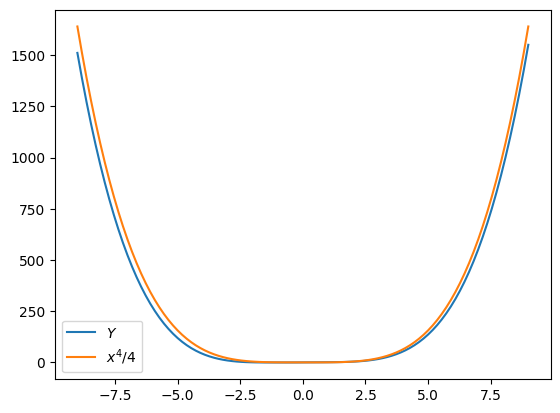

In [10]:
xs = np.linspace(-9, 9, 100)
Y_fun = sp.lambdify(x, Y, 'numpy')
plt.plot(xs, Y_fun(xs), label='$Y$')
plt.plot(xs, xs**4/4, label='$x^4/4$')
plt.legend()

Exercise 2

In [12]:
x, a, b, c, d = sp.symbols('x a b c d', real=True, positive=True)

In [18]:
y = (a*x**2 + b)/(c*x**2 + d)
Y = sp.simplify(sp.integrate(y, x))
display(Latex("Here we consider the function $y=" + sp.latex(y) + "$."))
display(Latex("The integral is $Y=" + sp.latex(Y) + "$."))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

7*x/2 - 31*atan(x/2)/4

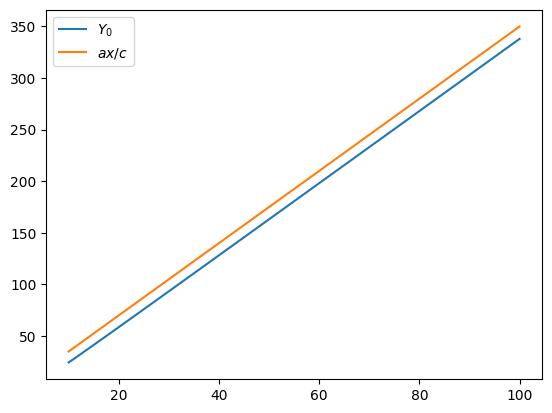

In [19]:
Y0 = Y.subs({a:7,b:-3,c:2,d:8})
m0 = (a/c).subs({a:7,b:-3,c:2,d:8})
display(Y0)
xs = np.linspace(10, 100, 100)
Y0_fun = sp.lambdify(x, Y0, 'numpy')
plt.plot(xs, Y0_fun(xs), label='$Y_0$')
plt.plot(xs, m0*xs,label='$ax/c$')
plt.legend()


Exercise 3

In [13]:
x, y, u, v, a = sp.symbols('x y u v a')

In [14]:
y = (8*x+8)/(x**2+2*x+3);
display(y)
display(ratint(y, x))

(8*x + 8)/(x**2 + 2*x + 3)

4*log(x**2 + 2*x + 3)

In [16]:
y = a*(2*x+u)/(x**2+u*x+v)
Y = sp.integrate(y, x)
display(y)
display(Y)


a*(u + 2*x)/(u*x + v + x**2)

a*log(u*x + v + x**2)

Exercise 3

Discriminant = -8


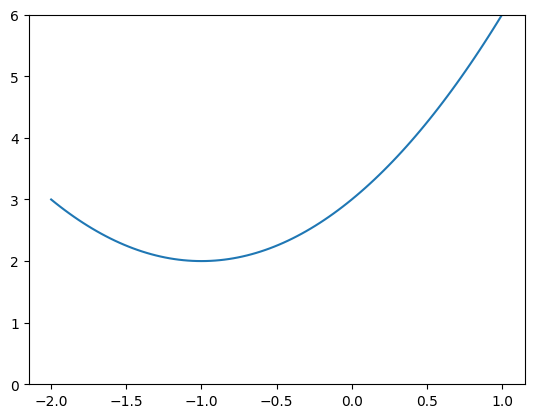

sqrt(2)*atan(sqrt(2)*x/2 + sqrt(2)/2)/2

In [17]:
q = x**2 + 2*x + 3
Delta = q.coeff(x, 1)**2 - 4*q.coeff(x, 2)*q.coeff(x, 0)
print(f"Discriminant = {Delta}")
xs = np.linspace(-2, 1, 100)
ys = sp.lambdify(x, q, 'numpy')(xs)
plt.plot(xs, ys)
plt.ylim(0, 6)
plt.show()
ratint(1/q, x)

Discriminant = 0


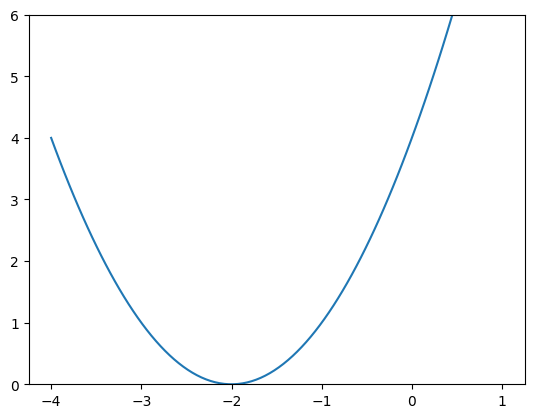

-1/(x + 2)

In [ ]:
q = x**2 + 4*x + 4
Delta = q.coeff(x, 1)**2 - 4*q.coeff(x, 2)*q.coeff(x, 0)
print(f"Discriminant = {Delta}")
xs = np.linspace(-4, 1, 100)
ys = sp.lambdify(x, q, 'numpy')(xs)
plt.plot(xs, ys)
plt.ylim(0, 6)
plt.show()
ratint(1/q, x)

Discriminant = 9


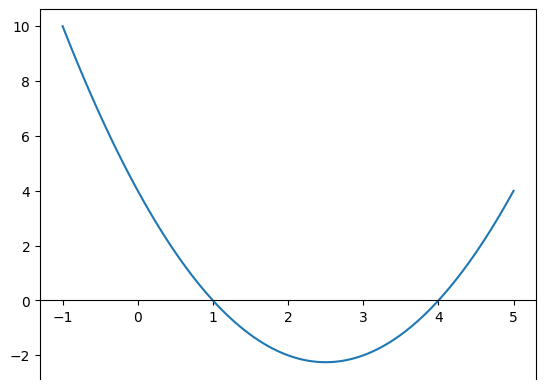

log(x - 4)/3 - log(x - 1)/3

In [18]:
q = x**2 - 5*x + 4
Delta = q.coeff(x, 1)**2 - 4*q.coeff(x, 2)*q.coeff(x, 0)
print(f"Discriminant = {Delta}")
xs = np.linspace(-1, 5, 100)
ys = sp.lambdify(x, q, 'numpy')(xs)
plt.plot(xs, ys)
plt.gca().spines['bottom'].set_position('zero')
plt.show()
ratint(1/q, x)

Exercise 5

1/(x**3 - 1) + 1/(x**2 - 1) + 1/(x - 1)

-log(x**2 + x + 1)/6 + 11*log(Abs(x - 1))/6 - log(Abs(x + 1))/2 - sqrt(3)*atan(2*sqrt(3)*x/3 + sqrt(3)/3)/3

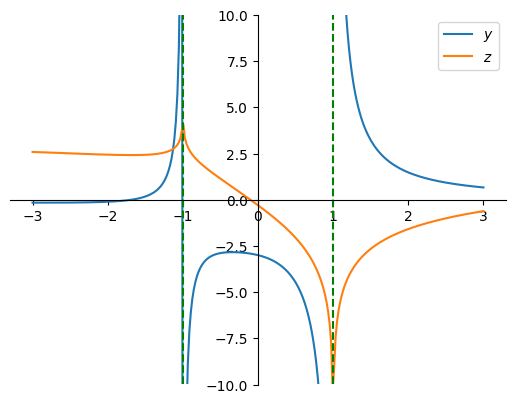

In [22]:
y = g[1]
z = ratint(y, x)
display(y)
display(z)
xs = np.linspace(-3, 3, 303)
ys = sp.lambdify(x, y, 'numpy')(xs)
zs = sp.lambdify(x, z, 'numpy')(xs)
ys = np.where(np.abs(ys) > 100, np.nan, ys)
zs = np.where(np.abs(zs) > 100, np.nan, zs)
plt.plot(xs, ys, label='$y$')
plt.plot(xs, zs, label='$z$')
plt.ylim(-10, 10)
plt.axvline(-1, color='g', linestyle='--')
plt.axvline( 1, color='g', linestyle='--')
fix_axes()
plt.legend()

(x - 1)**(-2) + (x - 2)**(-3) + (x - 3)**(-4)

-1/(x - 1) - 1/(2*(x - 2)**2) - 1/(3*(x - 3)**3)

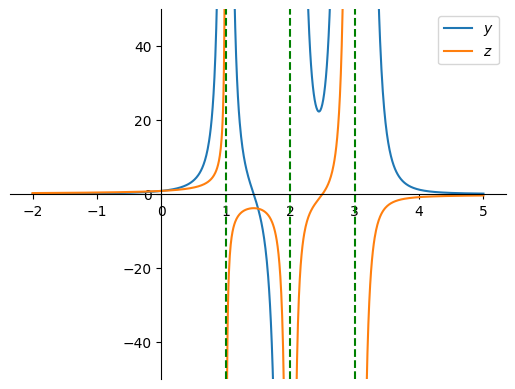

In [24]:
y = g[2]
z = ratint(y, x)
display(y)
display(z)
xs = np.linspace(-2, 5, 1000)
ys = sp.lambdify(x, y, 'numpy')(xs)
zs = sp.lambdify(x, z, 'numpy')(xs)
ys = np.where(np.abs(ys) > 100, np.nan, ys)
zs = np.where(np.abs(zs) > 100, np.nan, zs)
plt.plot(xs, ys, label='$y$')
plt.plot(xs, zs, label='$z$')
plt.ylim(-50, 50)
plt.axvline(1, color='g', linestyle='--')
plt.axvline(2, color='g', linestyle='--')
plt.axvline(3, color='g', linestyle='--')
fix_axes()
plt.legend()

1/(x**3 + 1) + 1/(x**2 + 1) + 1/(x + 1)

4*log(Abs(x + 1))/3 - log(Abs(x**2 - x + 1))/6 + atan(x) + sqrt(3)*atan(2*sqrt(3)*x/3 - sqrt(3)/3)/3

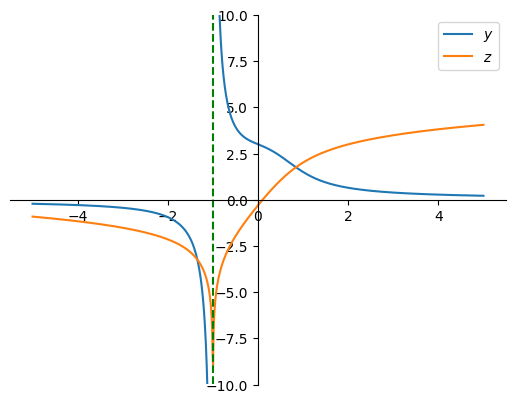

In [26]:
y = g[3]
z = ratint(y, x)
display(y)
display(z)
xs = np.linspace(-5, 5, 1000)
ys = sp.lambdify(x, y, 'numpy')(xs)
zs = sp.lambdify(x, z, 'numpy')(xs)
ys = np.where(np.abs(ys) > 100, np.nan, ys)
zs = np.where(np.abs(zs) > 100, np.nan, zs)
plt.plot(xs, ys, label='$y$')
plt.plot(xs, zs, label='$z$')
plt.ylim(-10, 10)
plt.axvline(-1, color='g', linestyle='--')
fix_axes()
plt.legend()

Exercise 6

(x - 1)**(-2) + (x - 2)**(-3) + (x - 3)**(-4)

(x - 3)**4*(x - 2)**3*(x - 1)**2

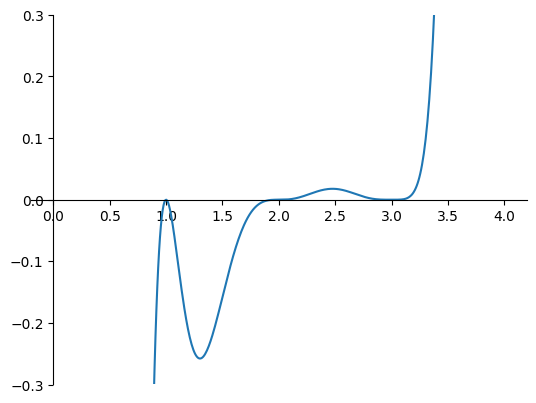

-1/(x - 1) - 1/(2*(x - 2)**2) - 1/(3*(x - 3)**3)

In [27]:
y = g[2]
display(y)
d = sp.denom(sp.factor(y))
display(d)
xs = np.linspace(0, 4, 500)
ys = sp.lambdify(x, d, 'numpy')(xs)
plt.plot(xs, ys)
plt.ylim(-0.3, 0.3)
fix_axes()
plt.show()
display(ratint(y, x))

1/(x**3 + 1) + 1/(x**2 + 1) + 1/(x + 1)

(x + 1)*(x**2 + 1)*(x**2 - x + 1)

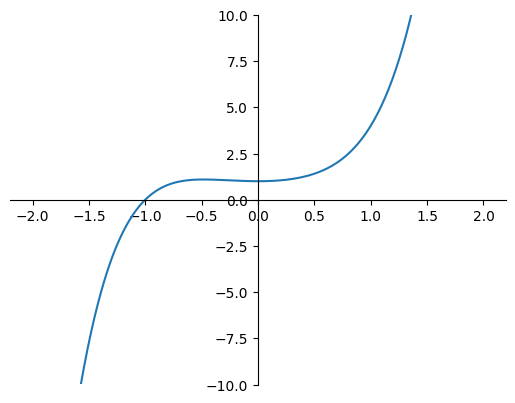

-log(x**2 - x + 1)/6 + 4*log(Abs(x + 1))/3 + atan(x) + sqrt(3)*atan(2*sqrt(3)*x/3 - sqrt(3)/3)/3

In [33]:
y = g[3]
display(y)
d = sp.denom(sp.factor(y))
display(d)
xs = np.linspace(-2, 2, 500)
ys = sp.lambdify(x, d, 'numpy')(xs)
plt.plot(xs, ys)
plt.ylim(-10, 10)
fix_axes()
plt.show()
display(ratint(y, x))

x*(x + 2)*(x + 4)/((x + 1)**2*(x + 3)**2)

(x + 1)**2*(x + 3)**2

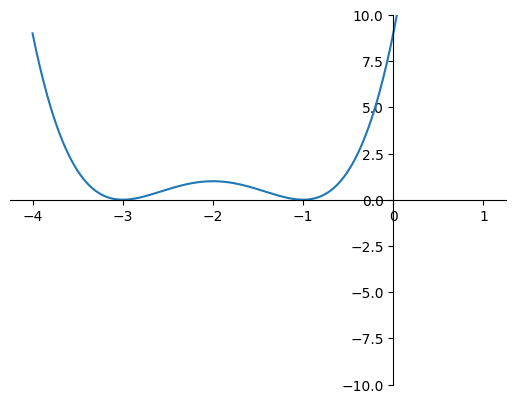

log(Abs(x + 1))/2 + log(Abs(x + 3))/2 - 3/(4*(x + 3)) + 3/(4*(x + 1))

In [28]:
y = g[5]
display(y)
d = sp.denom(sp.factor(y))
display(d)
xs = np.linspace(-4, 1, 500)
ys = sp.lambdify(x, d, 'numpy')(xs)
plt.plot(xs, ys)
plt.ylim(-10, 10)
fix_axes()
plt.show()
display(ratint(y, x))

In [34]:
def randpoly(x, degree=3, coef_range=(-10, 10)):
    N = degree + 1
    a = np.random.randint(*coef_range, N)
    f = sp.Add(*[a[i] * x **i for i in range(N)])
    return f    


In [40]:
x = sp.symbols('x', real=True)

In [44]:
xs = np.pi * np.linspace(-5, 5, 10) + np.exp(1)
f = randpoly(x, 3) / randpoly(x, 4)
F = ratint(f, x)
err0 = sp.simplify(sp.diff(F,x) - f)
err1 = [np.abs(err0.subs(x, x0).evalf()) for x0 in xs]
err2 = np.max(err1)
display(f)
display(F)
print(err2)


(-8*x**3 + 9*x**2 + 8*x - 5)/(2*x**4 - 10*x**3 - 5*x**2 + 6*x - 6)

-2.87317480083178*log(Abs(x - 5.38028553562129)) - 0.299150525859766*log(Abs(x + 1.17277054445276)) - 0.413837336654228*log(Abs(x**2 - 0.792485008831463*x + 0.475447841987173)) - 0.114077066915241*atan(1.7720924836985*x - 0.702178363796988)

2.96898907436647e-15
